In [1]:
!pip install ipython-autotime

In [2]:
%load_ext autotime

time: 305 µs (started: 2021-09-09 06:20:41 -07:00)


## 4.3 Imports<a id='4.3_Imports'></a>

In [3]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
import datetime

time: 1.14 s (started: 2021-09-09 06:20:41 -07:00)


In [4]:
#return the first 5 and last 5 rows of this dataframe
def p(df_):
    if df_.shape[0] > 6:
        print(df_.shape)
        return pd.concat([df_.head(), df_.tail()])
    else:
        return df_

def rcp(file_, pd_=None, ic_=None):
    if (pd_ == None) and (ic_ == None):
        return pd.read_csv(os.path.join('..', 'processed_data', file_))
    elif (pd_ != None) and (ic_ == None):
        return pd.read_csv(os.path.join('..', 'processed_data', file_), parse_dates=pd_)
    elif (pd_ != None) and (ic_ != None):
        return pd.read_csv(os.path.join('..', 'processed_data', file_), parse_dates=pd_, index_col = ic_)
    else:
        return pd.read_csv(os.path.join('..', 'processed_data', file_), index_col = ic_)
    
def rcr(file_, pd_=None):
    if pd_ == None:
        return pd.read_csv(os.path.join('..', 'raw_data', file_))
    else:
        return pd.read_csv(os.path.join('..', 'raw_data', file_), parse_dates=pd_)
    
#sort dataframe by column
def s(df_, column_):
    return df_.sort_values(column_)

#reset index and sort dataframe by column
def sr(df_, column_, ascending_=True):
    df_ = df_.sort_values(column_, ascending=ascending_)
    return df_.reset_index(drop=True)

#print length of list
def pl(list_):
    print(len(list_))
    return list_

#print length of dictionary
def pdc(dict_):
    print(len(dict_))
    return dict_

time: 737 µs (started: 2021-09-09 06:20:42 -07:00)


In [5]:
def MAPE(Y_actual,Y_Predicted):
    mape = np.mean(np.abs((Y_actual - Y_Predicted)/Y_actual))*100
    return mape

time: 259 µs (started: 2021-09-09 06:20:42 -07:00)


## 4.4 Load Data<a id='4.4_Load_Data'></a>

In [6]:
df_train = rcp('161_train_split_time_series_210_420_features.csv', None, 0)
p(df_train)

(9239, 211)


,lc_max_E_DEF_RATING_cmax5_diff,E_USG_PCT_cmax999_diff,DEF_RATING_sm_cma12_diff,REB_PCT_sm_cmax12_diff,lc_max_PACE_cmax12_diff,E_PACE_cmax999_diff,lc_max_POSS_cmax12_diff,lc_max_USG_PCT_cmax5_diff,DEF_RATING_sm_cmax12_diff,lc_sum_AST_RATIO_cma12_diff,...,lc_mean_E_USG_PCT_cma12_diff,E_OFF_RATING_cmax999_diff,PACE_PER40_cma5_diff,USG_PCT_cmax999_diff,lc_max_USG_PCT_cma999_diff,lc_sum_DREB_PCT_cma5_diff,E_TM_TOV_PCT_cma_sm_cmax12_diff,pf_cmax12_diff,lc_max_E_PACE_cmax999_diff,spread_a
0,-0.031859,-0.003876,0.019367,0.032819,-0.013625,-0.028242,-0.044331,-0.024069,0.016839,-0.100250,...,-0.056732,-0.037081,-0.023064,-0.006580,-0.094783,0.008994,0.025342,0.104586,-0.000796,-8
1,-0.031859,-0.003876,0.019367,0.032819,-0.013625,-0.028242,-0.044331,-0.024069,0.016839,-0.100250,...,-0.056732,-0.037081,-0.023064,-0.006580,-0.094783,0.008994,0.025342,0.104586,-0.000796,14
2,-0.031859,-0.003876,0.019367,0.032819,-0.013625,-0.028242,-0.044331,-0.024069,0.016839,-0.100250,...,-0.056732,-0.037081,-0.023064,-0.006580,-0.094783,0.008994,0.025342,0.104586,-0.000796,2
3,-0.031859,-0.003876,0.019367,0.032819,-0.013625,-0.028242,-0.044331,-0.024069,0.016839,-0.100250,...,-0.056732,-0.037081,-0.023064,-0.006580,-0.094783,0.008994,0.025342,0.104586,-0.000796,1
4,3.728147,17.039359,0.019367,0.032819,0.589506,12.209995,4.292093,2.463662,0.016839,2.889242,...,3.855287,8.043184,13.078191,16.880664,3.172801,2.612696,0.025342,4.488641,0.516524,-10
9234,0.031798,0.166556,0.019367,0.032819,-0.032390,-0.351920,-1.046412,0.086950,0.016839,2.788915,...,-0.608688,-0.018696,0.733286,-0.006580,-0.313824,0.448694,0.025342,-1.148002,-0.018188,-3
9235,-1.988878,0.081340,1.545816,1.727230,-0.094954,-0.087092,-0.683095,0.860277,1.440637,-1.755166,...,1.563764,-1.094226,-0.333027,-0.006580,0.822523,2.321085,-0.236361,-0.521708,0.007686,-16
9236,-0.203505,0.081340,0.019367,0.032819,-1.604741,-1.392504,-1.192813,0.045942,0.016839,-0.741326,...,0.864621,-0.882797,-0.046775,-0.006580,0.976889,-1.648276,0.025342,0.313350,-0.069030,-10
9237,0.386570,-0.174309,-2.073182,0.032819,-0.075135,0.640515,0.326186,1.188972,-1.934989,-1.120473,...,0.362430,0.459318,0.793080,-0.006580,1.173419,0.676634,-0.319505,0.313350,-0.070975,-15
9238,2.209654,0.166556,-0.607386,-0.542071,-0.074032,0.159010,0.917712,3.785269,-0.567766,-2.226740,...,4.453300,1.920936,0.392052,-0.006580,6.916668,-1.116575,-1.060929,0.730879,-0.101425,-15


time: 296 ms (started: 2021-09-09 06:20:42 -07:00)


In [7]:
df_test = rcp('161_test_split_time_series_210_420_features.csv', None, 0)
p(df_test)

(1027, 211)


,lc_max_E_DEF_RATING_cmax5_diff,E_USG_PCT_cmax999_diff,DEF_RATING_sm_cma12_diff,REB_PCT_sm_cmax12_diff,lc_max_PACE_cmax12_diff,E_PACE_cmax999_diff,lc_max_POSS_cmax12_diff,lc_max_USG_PCT_cmax5_diff,DEF_RATING_sm_cmax12_diff,lc_sum_AST_RATIO_cma12_diff,...,lc_mean_E_USG_PCT_cma12_diff,E_OFF_RATING_cmax999_diff,PACE_PER40_cma5_diff,USG_PCT_cmax999_diff,lc_max_USG_PCT_cma999_diff,lc_sum_DREB_PCT_cma5_diff,E_TM_TOV_PCT_cma_sm_cmax12_diff,pf_cmax12_diff,lc_max_E_PACE_cmax999_diff,spread_a
9239,0.362017,0.166556,0.019367,0.032819,0.236493,-0.822724,0.484779,2.313577,0.016839,0.514627,...,0.210788,-0.046274,-0.485603,-0.00658,1.094839,0.406924,0.025342,0.522115,-0.033839,13
9240,-0.454722,-0.089093,0.615795,1.182598,0.112683,-0.322494,0.418083,0.580886,0.573158,2.079262,...,1.400377,-0.671368,1.021944,-0.00658,1.498846,-1.940506,0.960357,0.313350,0.042045,7
9241,-2.473550,-0.003876,0.019367,0.032819,-0.005482,1.702499,0.039075,0.606908,0.016839,-0.183914,...,0.335845,0.238696,0.850124,-0.00658,0.274145,1.212783,0.025342,0.522115,-0.045827,-10
9242,0.594762,-0.089093,0.787646,0.032819,0.038143,-1.395179,0.401038,-0.049597,0.733453,-1.316430,...,-0.316700,-0.441554,-1.278723,-0.00658,-0.850895,-1.444994,0.317125,-1.565531,-0.032899,-11
9243,-0.451582,-0.089093,0.019367,0.032819,-0.067580,0.295436,0.316203,-1.010577,0.016839,-0.830851,...,-0.981007,0.155963,0.325386,-0.00658,-0.677906,-0.935856,0.025342,0.939644,-0.010575,10
10261,0.051076,-0.003876,-0.609633,-0.133597,-0.066980,0.274036,-0.859372,-0.343577,-0.482904,-0.204399,...,-0.306157,0.569628,-0.023064,-0.00658,1.005161,-0.533730,0.817850,0.104586,0.026765,-9
10262,0.166594,-0.003876,0.939280,0.017690,0.058857,0.501413,-0.210736,0.132700,0.931464,0.013700,...,-0.204555,-0.358821,-0.238182,-0.00658,-0.920252,-0.522050,-0.884331,-0.104179,0.001760,10
10263,0.166594,-0.003876,1.050479,0.925410,0.058857,0.501413,-0.210736,0.132700,1.186050,-0.242005,...,-0.464395,-0.358821,-0.152273,-0.00658,-0.937520,-0.635729,-0.884331,-0.104179,0.001760,19
10264,0.131830,-0.003876,1.389128,0.925410,0.057262,0.501413,-0.210736,0.161685,1.610361,-0.175509,...,-0.421676,-0.358821,-0.309659,-0.00658,-0.928759,-0.321325,-0.884331,-0.312943,0.001760,8
10265,0.200079,-0.003876,1.309267,0.925410,0.096277,0.501413,-0.210736,0.359016,1.610361,-0.158402,...,-0.716825,-0.358821,-0.280794,-0.00658,-0.909101,0.232398,-0.884331,-0.312943,0.001760,23


time: 49.9 ms (started: 2021-09-09 06:20:42 -07:00)


In [8]:
X_train = df_train.drop(columns = 'spread_a')
p(X_train)

(9239, 210)


,lc_max_E_DEF_RATING_cmax5_diff,E_USG_PCT_cmax999_diff,DEF_RATING_sm_cma12_diff,REB_PCT_sm_cmax12_diff,lc_max_PACE_cmax12_diff,E_PACE_cmax999_diff,lc_max_POSS_cmax12_diff,lc_max_USG_PCT_cmax5_diff,DEF_RATING_sm_cmax12_diff,lc_sum_AST_RATIO_cma12_diff,...,lc_max_TS_PCT_cma12_diff,lc_mean_E_USG_PCT_cma12_diff,E_OFF_RATING_cmax999_diff,PACE_PER40_cma5_diff,USG_PCT_cmax999_diff,lc_max_USG_PCT_cma999_diff,lc_sum_DREB_PCT_cma5_diff,E_TM_TOV_PCT_cma_sm_cmax12_diff,pf_cmax12_diff,lc_max_E_PACE_cmax999_diff
0,-0.031859,-0.003876,0.019367,0.032819,-0.013625,-0.028242,-0.044331,-0.024069,0.016839,-0.100250,...,0.003558,-0.056732,-0.037081,-0.023064,-0.006580,-0.094783,0.008994,0.025342,0.104586,-0.000796
1,-0.031859,-0.003876,0.019367,0.032819,-0.013625,-0.028242,-0.044331,-0.024069,0.016839,-0.100250,...,0.003558,-0.056732,-0.037081,-0.023064,-0.006580,-0.094783,0.008994,0.025342,0.104586,-0.000796
2,-0.031859,-0.003876,0.019367,0.032819,-0.013625,-0.028242,-0.044331,-0.024069,0.016839,-0.100250,...,0.003558,-0.056732,-0.037081,-0.023064,-0.006580,-0.094783,0.008994,0.025342,0.104586,-0.000796
3,-0.031859,-0.003876,0.019367,0.032819,-0.013625,-0.028242,-0.044331,-0.024069,0.016839,-0.100250,...,0.003558,-0.056732,-0.037081,-0.023064,-0.006580,-0.094783,0.008994,0.025342,0.104586,-0.000796
4,3.728147,17.039359,0.019367,0.032819,0.589506,12.209995,4.292093,2.463662,0.016839,2.889242,...,4.543214,3.855287,8.043184,13.078191,16.880664,3.172801,2.612696,0.025342,4.488641,0.516524
9234,0.031798,0.166556,0.019367,0.032819,-0.032390,-0.351920,-1.046412,0.086950,0.016839,2.788915,...,0.504253,-0.608688,-0.018696,0.733286,-0.006580,-0.313824,0.448694,0.025342,-1.148002,-0.018188
9235,-1.988878,0.081340,1.545816,1.727230,-0.094954,-0.087092,-0.683095,0.860277,1.440637,-1.755166,...,-0.966703,1.563764,-1.094226,-0.333027,-0.006580,0.822523,2.321085,-0.236361,-0.521708,0.007686
9236,-0.203505,0.081340,0.019367,0.032819,-1.604741,-1.392504,-1.192813,0.045942,0.016839,-0.741326,...,0.480475,0.864621,-0.882797,-0.046775,-0.006580,0.976889,-1.648276,0.025342,0.313350,-0.069030
9237,0.386570,-0.174309,-2.073182,0.032819,-0.075135,0.640515,0.326186,1.188972,-1.934989,-1.120473,...,-0.690769,0.362430,0.459318,0.793080,-0.006580,1.173419,0.676634,-0.319505,0.313350,-0.070975
9238,2.209654,0.166556,-0.607386,-0.542071,-0.074032,0.159010,0.917712,3.785269,-0.567766,-2.226740,...,1.944562,4.453300,1.920936,0.392052,-0.006580,6.916668,-1.116575,-1.060929,0.730879,-0.101425


time: 18.1 ms (started: 2021-09-09 06:20:42 -07:00)


In [9]:
y_train = df_train.spread_a
p(y_train)

(9239,)


0       -8
1       14
2        2
3        1
4      -10
9234    -3
9235   -16
9236   -10
9237   -15
9238   -15
Name: spread_a, dtype: int64

time: 2.22 ms (started: 2021-09-09 06:20:42 -07:00)


In [10]:
X_test = df_test.drop(columns = 'spread_a')
p(X_test)

(1027, 210)


,lc_max_E_DEF_RATING_cmax5_diff,E_USG_PCT_cmax999_diff,DEF_RATING_sm_cma12_diff,REB_PCT_sm_cmax12_diff,lc_max_PACE_cmax12_diff,E_PACE_cmax999_diff,lc_max_POSS_cmax12_diff,lc_max_USG_PCT_cmax5_diff,DEF_RATING_sm_cmax12_diff,lc_sum_AST_RATIO_cma12_diff,...,lc_max_TS_PCT_cma12_diff,lc_mean_E_USG_PCT_cma12_diff,E_OFF_RATING_cmax999_diff,PACE_PER40_cma5_diff,USG_PCT_cmax999_diff,lc_max_USG_PCT_cma999_diff,lc_sum_DREB_PCT_cma5_diff,E_TM_TOV_PCT_cma_sm_cmax12_diff,pf_cmax12_diff,lc_max_E_PACE_cmax999_diff
9239,0.362017,0.166556,0.019367,0.032819,0.236493,-0.822724,0.484779,2.313577,0.016839,0.514627,...,-0.236712,0.210788,-0.046274,-0.485603,-0.00658,1.094839,0.406924,0.025342,0.522115,-0.033839
9240,-0.454722,-0.089093,0.615795,1.182598,0.112683,-0.322494,0.418083,0.580886,0.573158,2.079262,...,1.378549,1.400377,-0.671368,1.021944,-0.00658,1.498846,-1.940506,0.960357,0.313350,0.042045
9241,-2.473550,-0.003876,0.019367,0.032819,-0.005482,1.702499,0.039075,0.606908,0.016839,-0.183914,...,0.371986,0.335845,0.238696,0.850124,-0.00658,0.274145,1.212783,0.025342,0.522115,-0.045827
9242,0.594762,-0.089093,0.787646,0.032819,0.038143,-1.395179,0.401038,-0.049597,0.733453,-1.316430,...,-0.411219,-0.316700,-0.441554,-1.278723,-0.00658,-0.850895,-1.444994,0.317125,-1.565531,-0.032899
9243,-0.451582,-0.089093,0.019367,0.032819,-0.067580,0.295436,0.316203,-1.010577,0.016839,-0.830851,...,0.103464,-0.981007,0.155963,0.325386,-0.00658,-0.677906,-0.935856,0.025342,0.939644,-0.010575
10261,0.051076,-0.003876,-0.609633,-0.133597,-0.066980,0.274036,-0.859372,-0.343577,-0.482904,-0.204399,...,-0.003129,-0.306157,0.569628,-0.023064,-0.00658,1.005161,-0.533730,0.817850,0.104586,0.026765
10262,0.166594,-0.003876,0.939280,0.017690,0.058857,0.501413,-0.210736,0.132700,0.931464,0.013700,...,-0.361711,-0.204555,-0.358821,-0.238182,-0.00658,-0.920252,-0.522050,-0.884331,-0.104179,0.001760
10263,0.166594,-0.003876,1.050479,0.925410,0.058857,0.501413,-0.210736,0.132700,1.186050,-0.242005,...,-0.667710,-0.464395,-0.358821,-0.152273,-0.00658,-0.937520,-0.635729,-0.884331,-0.104179,0.001760
10264,0.131830,-0.003876,1.389128,0.925410,0.057262,0.501413,-0.210736,0.161685,1.610361,-0.175509,...,-0.667505,-0.421676,-0.358821,-0.309659,-0.00658,-0.928759,-0.321325,-0.884331,-0.312943,0.001760
10265,0.200079,-0.003876,1.309267,0.925410,0.096277,0.501413,-0.210736,0.359016,1.610361,-0.158402,...,-1.023071,-0.716825,-0.358821,-0.280794,-0.00658,-0.909101,0.232398,-0.884331,-0.312943,0.001760


time: 14.2 ms (started: 2021-09-09 06:20:42 -07:00)


In [11]:
y_test = df_test.spread_a
p(y_test)

(1027,)


9239     13
9240      7
9241    -10
9242    -11
9243     10
10261    -9
10262    10
10263    19
10264     8
10265    23
Name: spread_a, dtype: int64

time: 2.26 ms (started: 2021-09-09 06:20:42 -07:00)


## 4.10 Random Forest Model<a id='4.10_Random_Forest_Model'></a>

A model that can work very well in a lot of cases is the random forest. For regression, this is provided by `sklearn`'s `RandomForestRegressor` class.

Time to stop the bad practice of repeatedly checking performance on the test split. Instead, go straight from defining the pipeline to assessing performance using cross-validation. `cross_validate` will perform the fitting as part of the process. This uses the default settings for the random forest so you'll then proceed to investigate some different hyperparameters.

### 4.10.1 Define the pipeline<a id='4.10.1_Define_the_pipeline'></a>

In [12]:
RF_pipe = make_pipeline(
    RandomForestRegressor(criterion = 'mae', random_state=47)
)

time: 336 µs (started: 2021-09-09 06:20:42 -07:00)


<font color='red'> default parameters of the RandomForestRegressor are?????</font>

min_samples_split=2,
max_features='auto'

In [13]:
type(RF_pipe)

sklearn.pipeline.Pipeline

time: 860 µs (started: 2021-09-09 06:20:42 -07:00)


In [14]:
hasattr(RF_pipe, 'fit'), hasattr(RF_pipe, 'predict')

(True, True)

time: 936 µs (started: 2021-09-09 06:20:42 -07:00)


### 4.10.2 Fit and assess performance using cross-validation<a id='4.10.2_Fit_and_assess_performance_using_cross-validation'></a>

In [15]:
#Code task 23#
#Call `cross_validate` to estimate the pipeline's performance.
#Pass it the random forest pipe object, `X_train` and `y_train`,
#and get it to use 5-fold cross-validation
rf_default_cv_results = cross_validate(RF_pipe, X_train, y_train, cv=5)

time: 3h 14min 38s (started: 2021-09-09 06:20:42 -07:00)


<font color='red'> specify you want mape or mae here instead of test_score?????????</font>

In [16]:
rf_cv_scores = rf_default_cv_results['test_score']
rf_cv_scores

array([0.19543217, 0.18439092, 0.1761742 , 0.19845941, 0.15217392])

time: 1.18 ms (started: 2021-09-09 09:35:21 -07:00)


<font color='red'> this is test score for the training set cv splits?????</font>

In [17]:
np.mean(rf_cv_scores), np.std(rf_cv_scores)

(0.18132612598546058, 0.016603109560677856)

time: 840 µs (started: 2021-09-09 09:35:21 -07:00)


In [18]:
#rf_cv_scores_mae = rf_default_cv_results['test_mae']
#rf_cv_scores_mae

time: 105 µs (started: 2021-09-09 09:35:21 -07:00)


In [19]:
#np.mean(rf_cv_scores_mae), np.std(rf_cv_scores_mae)

time: 105 µs (started: 2021-09-09 09:35:21 -07:00)


<font color='red'> this 'test_mae' the correct syntax???? </font>

In [20]:
#https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html

time: 112 µs (started: 2021-09-09 09:35:21 -07:00)


### 4.10.3 Hyperparameter search using GridSearchCV<a id='4.10.3_Hyperparameter_search_using_GridSearchCV'></a>

Random forest has a number of hyperparameters that can be explored, however here you'll limit yourselves to exploring some different values for the number of trees. You'll try it with and without feature scaling, and try both the mean and median as strategies for imputing missing values.

In [21]:
#n_est = [int(n) for n in np.logspace(start=1, stop=3, num=20)]

grid_params = {
        'randomforestregressor__n_estimators': [200],
        'randomforestregressor__max_depth': [5, 10, 20, 1000],
        'randomforestregressor__min_samples_split': [50, 100, 1000]
}
grid_params

{'randomforestregressor__n_estimators': [200],
 'randomforestregressor__max_depth': [5, 10, 20, 1000],
 'randomforestregressor__min_samples_split': [50, 100, 1000]}

time: 1.48 ms (started: 2021-09-09 09:35:21 -07:00)


In [22]:
#Code task 24#
#Call `GridSearchCV` with the random forest pipeline, passing in the above `grid_params`
#dict for parameters to evaluate, 5-fold cross-validation, and all available CPU cores (if desired)
rf_grid_cv = GridSearchCV(RF_pipe, param_grid=grid_params, cv=5, n_jobs=-1)

time: 281 µs (started: 2021-09-09 09:35:21 -07:00)


In [23]:
#Code task 25#
#Now call the `GridSearchCV`'s `fit()` method with `X_train` and `y_train` as arguments
#to actually start the grid search. This may take a minute or two.
rf_grid_cv.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('randomforestregressor',
                                        RandomForestRegressor(criterion='mae',
                                                              random_state=47))]),
             n_jobs=-1,
             param_grid={'randomforestregressor__max_depth': [5, 10, 20, 1000],
                         'randomforestregressor__min_samples_split': [50, 100,
                                                                      1000],
                         'randomforestregressor__n_estimators': [200]})

time: 13h 2min 59s (started: 2021-09-09 09:35:21 -07:00)


In [24]:
#Code task 26#
#Print the best params (`best_params_` attribute) from the grid search
rf_grid_cv.best_params_

{'randomforestregressor__max_depth': 5,
 'randomforestregressor__min_samples_split': 50,
 'randomforestregressor__n_estimators': 200}

time: 1.01 ms (started: 2021-09-09 22:38:23 -07:00)


It looks like imputing with the median helps, but scaling the features doesn't.

In [25]:
rf_best_cv_results = cross_validate(rf_grid_cv.best_estimator_, X_train, y_train, cv=5)
rf_best_scores = rf_best_cv_results['test_score']
rf_best_scores

array([0.20241634, 0.19321237, 0.18457354, 0.20625189, 0.16068457])

time: 4h 39min 2s (started: 2021-09-09 22:38:23 -07:00)


<font color='red'> why is this cross-validatino repeated when it was just done above in GridSearchCV????</font>

In [26]:
np.mean(rf_best_scores), np.std(rf_best_scores)

(0.18942774190819395, 0.016222279842285036)

time: 1.94 ms (started: 2021-09-10 03:59:52 -07:00)


You've marginally improved upon the default CV results. Random forest has many more hyperparameters you could tune, but we won't dive into that here.

<font color='red'>what hyperparameters did we just tune???????? n_est????????<font>

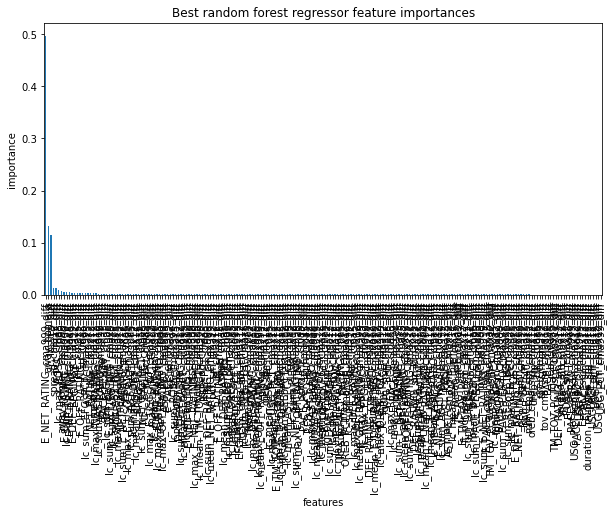

time: 2.2 s (started: 2021-09-10 03:59:52 -07:00)


In [27]:
#Code task 27#
#Plot a barplot of the random forest's feature importances,
#assigning the `feature_importances_` attribute of 
#`rf_grid_cv.best_estimator_.named_steps.randomforestregressor` to the name `imps` to then
#create a pandas Series object of the feature importances, with the index given by the
#training data column names, sorting the values in descending order
plt.subplots(figsize=(10, 5))
imps = rf_grid_cv.best_estimator_.named_steps.randomforestregressor.feature_importances_
rf_feat_imps = pd.Series(imps, index=X_train.columns).sort_values(ascending=False)
rf_feat_imps.plot(kind='bar')
plt.xlabel('features')
plt.ylabel('importance')
plt.title('Best random forest regressor feature importances');

In [28]:
rf_feat_imps

E_NET_RATING_cma999_diff    0.497174
away_home_a                 0.132745
losses_diff                 0.115545
spread_cma12_diff           0.013032
w_pct_cma5_diff             0.012360
                              ...   
PACE_sm_cma12_diff          0.000000
USG_PCT_sm_cma12_diff       0.000000
USG_PCT_cma12_diff          0.000000
USG_PCT_sm_cmax12_diff      0.000000
USG_PCT_cma999_diff         0.000000
Length: 210, dtype: float64

time: 1.76 ms (started: 2021-09-10 03:59:55 -07:00)


In [29]:
rf_feat_imps[0:30]

E_NET_RATING_cma999_diff           0.497174
away_home_a                        0.132745
losses_diff                        0.115545
spread_cma12_diff                  0.013032
w_pct_cma5_diff                    0.012360
lc_max_POSS_cma5_diff              0.008304
away_home__cma999_diff             0.006172
E_OFF_RATING_cma999_diff           0.005394
lc_sum_TS_PCT_cma999_diff          0.004608
E_NET_RATING_cmax5_diff            0.004386
E_DEF_RATING_cma999_diff           0.004111
EFG_PCT_cma12_diff                 0.003770
PIE_cmax5_diff                     0.003556
E_OFF_RATING_cma12_diff            0.002959
stl_cma5_diff                      0.002865
lc_sum_EFG_PCT_cmax999_diff        0.002563
AST_PCT_cmax5_diff                 0.002437
NET_RATING_cmax12_diff             0.002389
lc_mean_PIE_cmax12_diff            0.002263
lc_max_NET_RATING_cma12_diff       0.002260
lc_sum_AST_RATIO_cma12_diff        0.002164
AST_RATIO_cma999_diff              0.002160
PACE_PER40_cma5_diff            

time: 1.45 ms (started: 2021-09-10 03:59:55 -07:00)


In [30]:
#feature importance affected by collinearity


#https://www.quora.com/Does-the-random-forests-technique-suffer-if-there-is-a-multi-colinerarity-present-in-the-features-data-when-trying-to-predict-the-classification-of-the-next-datapoint-If-not-why



time: 100 µs (started: 2021-09-10 03:59:55 -07:00)


In [31]:
# can reduce runtime by dropping the bottom 5% of feature importances

#https://towardsdatascience.com/improving-random-forest-in-python-part-1-893916666cd




time: 112 µs (started: 2021-09-10 03:59:55 -07:00)


In [32]:
#play with max depth

#specify maximum number of features to include in each node split


#https://www.keboola.com/blog/random-forest-regression

time: 116 µs (started: 2021-09-10 03:59:55 -07:00)


In [33]:
#Random Search Cross Validation

#https://towardsdatascience.com/hyperparameter-tuning-the-random-forest-in-python-using-scikit-learn-28d2aa77dd74


#random_grid = {'n_estimators': n_estimators,
#               'max_features': max_features,
#               'max_depth': max_depth,
#               'min_samples_split': min_samples_split,
#               'min_samples_leaf': min_samples_leaf,
#               'bootstrap': bootstrap}



time: 121 µs (started: 2021-09-10 03:59:55 -07:00)


## 4.11 Final Model Selection<a id='4.11_Final_Model_Selection'></a>

Time to select your final model to use for further business modeling! It would be good to revisit the above model selection; there is undoubtedly more that could be done to explore possible hyperparameters.
It would also be worthwhile to investigate removing the least useful features. Gathering or calculating, and storing, features adds business cost and dependencies, so if features genuinely are not needed they should be removed.
Building a simpler model with fewer features can also have the advantage of being easier to sell (and/or explain) to stakeholders.
Certainly there seem to be four strong features here and so a model using only those would probably work well.
However, you want to explore some different scenarios where other features vary so keep the fuller 
model for now. 
The business is waiting for this model and you have something that you have confidence in to be much better than guessing with the average price.

Or, rather, you have two "somethings". You built a best linear model and a best random forest model. You need to finally choose between them. You can calculate the mean absolute error using cross-validation. Although `cross-validate` defaults to the $R^2$ [metric for scoring](https://scikit-learn.org/stable/modules/model_evaluation.html#scoring) regression, you can specify the mean absolute error as an alternative via
the `scoring` parameter.

### 4.11.1 Linear regression model performance<a id='4.11.1_Linear_regression_model_performance'></a>

### 4.11.2 Random forest regression model performance<a id='4.11.2_Random_forest_regression_model_performance'></a>

In [34]:
rf_neg_mae = cross_validate(rf_grid_cv.best_estimator_, X_train, y_train, 
                            scoring='neg_mean_absolute_error', cv=5, n_jobs=-1)

time: 1h 7min 52s (started: 2021-09-10 03:59:55 -07:00)


In [35]:
rf_mae_mean = np.mean(-1 * rf_neg_mae['test_score'])
rf_mae_std = np.std(-1 * rf_neg_mae['test_score'])
rf_mae_mean, rf_mae_std

(9.648847702164737, 0.39408631777634456)

time: 2.31 ms (started: 2021-09-10 05:07:48 -07:00)


In [36]:
mean_absolute_error(y_test, rf_grid_cv.best_estimator_.predict(X_test))

9.714221032132425

time: 25 ms (started: 2021-09-10 05:07:48 -07:00)


In [37]:
MAPE(y_test, rf_grid_cv.best_estimator_.predict(X_test))

112.64294071964012

time: 40.7 ms (started: 2021-09-10 05:07:48 -07:00)


### 4.11.3 Conclusion<a id='4.11.3_Conclusion'></a>

The random forest model has a cross-validation mean absolute error... It also exhibits ... variability. 

???Verifying performance on the test set produces performance consistent with the cross-validation results????

## 4.12 Data quantity assessment<a id='4.12_Data_quantity_assessment'></a>

Finally, you need to advise the business whether it needs to undertake further data collection. Would more data be useful? We're often led to believe more data is always good, but gathering data invariably has a cost associated with it. Assess this trade off by seeing how performance varies with differing data set sizes. The `learning_curve` function does this conveniently.

In [38]:
fractions = [.2, .25, .3, .35, .4, .45, .5, .6, .75, .8, 1.0]
train_size, train_scores, test_scores = learning_curve(RF_pipe, X_train, y_train, train_sizes=fractions)
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

time: 12h 6min 58s (started: 2021-09-10 05:07:48 -07:00)


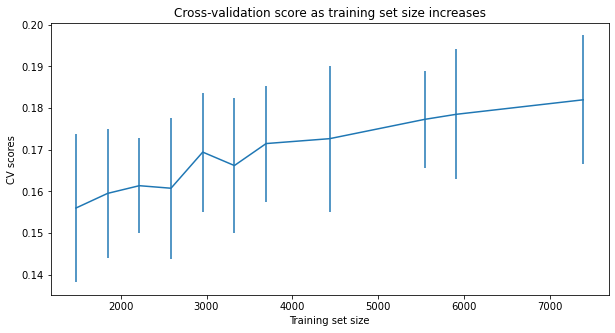

time: 87.3 ms (started: 2021-09-10 17:14:46 -07:00)


In [39]:
plt.subplots(figsize=(10, 5))
plt.errorbar(train_size, test_scores_mean, yerr=test_scores_std)
plt.xlabel('Training set size')
plt.ylabel('CV scores')
plt.title('Cross-validation score as training set size increases');

This shows that you seem to have plenty of data. There's an initial rapid improvement in model scores as one would expect, but it's essentially levelled off by around a sample size of 40-50.

## 4.13 Save best model object from pipeline<a id='4.13_Save_best_model_object_from_pipeline'></a>

In [40]:
#This may not be "production grade ML deployment" practice, but adding some basic
#information to your saved models can save your bacon in development.
#Just what version model have you just loaded to reuse? What version of `sklearn`
#created it? When did you make it?
#Assign the pandas version number (`pd.__version__`) to the `pandas_version` attribute,
#the numpy version (`np.__version__`) to the `numpy_version` attribute,
#the sklearn version (`sklearn_version`) to the `sklearn_version` attribute,
#and the current datetime (`datetime.datetime.now()`) to the `build_datetime` attribute
#Let's call this model version '1.0'
best_model = rf_grid_cv.best_estimator_
best_model.version = '1.0'
best_model.pandas_version = pd.__version__
best_model.numpy_version = np.__version__
best_model.sklearn_version = sklearn_version
best_model.X_columns = [col for col in X_train.columns]
best_model.build_datetime = datetime.datetime.now()
    
modelpath = os.path.join('..', 'models')
if not os.path.exists(modelpath):
    os.mkdir(modelpath)
nbamodel_path = os.path.join(modelpath, '161_210_420_features_trial_1.pkl')
if not os.path.exists(nbamodel_path):
    with open(nbamodel_path, 'wb') as f:
        pickle.dump(best_model, f)

time: 6.74 ms (started: 2021-09-10 17:14:46 -07:00)


## 4.14 Summary<a id='4.14_Summary'></a>

**Q: 1** Write a summary of the work in this notebook. Capture the fact that you gained a baseline idea of performance by simply taking the average price and how well that did. Then highlight that you built a linear model and the features that found. Comment on the estimate of its performance from cross-validation and whether its performance on the test split was consistent with this estimate. Also highlight that a random forest regressor was tried, what preprocessing steps were found to be best, and again what its estimated performance via cross-validation was and whether its performance on the test set was consistent with that. State which model you have decided to use going forwards and why. This summary should provide a quick overview for someone wanting to know quickly why the given model was chosen for the next part of the business problem to help guide important business decisions.

Capture the fact that you gained a baseline idea of performance by simply taking the average price and how well that did.
-Average price yielded an R^2, explained variance, of 0 and a mean absolute error of 18 and 19 on the training (i.e. y_train) and testing (i.e. y_train) sets respectively when compared to their predicted average 'AdultWeekend' ticket price (i.e. y_tr_pred).

Then highlight that you built a linear model and the features that found.
-In building a linear model, features found (using GridSearchCV) included vertical_drop, Snow Making_ac, total_chairs, fastQuads, Runs, LongestRun_mi, trams, SkiableTerrain_ac. In selecting eight (8) features (i.e. hyperparameter k=8) in linear regression to predict 'AdultWeekend' ticket price (i.e. y_train and y_test), the cross validation average test score of R^2 (i.e. explained variance) performance reached a maximum.


Comment on the estimate of its performance from cross-validation and whether its performance on the test split was consistent with this estimate.
-Cross-validation (with number of folds k=5) performance using linear regression model with 15 features (i.e. pipe15) showed an average R^2 score of .6349 and average std of .095. Using the pipe15 model, mean explained variance R^2 of cross-validation is close to the test split R^2 score .6347.


Also highlight that a random forest regressor was tried, what preprocessing steps were found to be best, and again what its estimated performance via cross-validation was and whether its performance on the test set was consistent with that. 
-Preprocessing steps that were found to be best included ?using n_est=69,? omitting the use of feature scaling, and using median instead of mean for feature imputing.
-The estimated performance of random forest regressor via cross-validation was a mean absolute error of 9.754 and standard deviation of 1.353.
-This performance was consistent with performance of the test set where mean absolute error was 9.342 using y_test and X_test.

State which model you have decided to use going forwards and why.
We have decided to go forwards with the random forest regression model because it yields the lower MAE (mean absolute error) between linear regression at 10.448 and random forest regression at 9.754, each by cross validation.